In [1]:
# Install HuggingFace libraries and Gradio
# These aren't pre-installed in Colab
!pip install -q transformers datasets gradio accelerate

print("Installation complete")

Installation complete


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             precision_score, recall_score)

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    DistilBertTokenizerFast,    # converts text to token IDs
    DistilBertForSequenceClassification,  # DistilBERT + classification head
    get_linear_schedule_with_warmup  # learning rate scheduler
)
from torch.optim import AdamW # optimiser designed for transformers

import gradio as gr  # for the demo UI

import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Should print: Using device: cuda
# If it prints 'cpu', go back and enable GPU in Runtime settings

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("All imports successful")

Using device: cuda
All imports successful


In [3]:
# Upload your kaggle.json first (same process as Project 1)
from google.colab import files
uploaded = files.upload()  # select kaggle.json

import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 600)

!pip install -q kaggle

# Download the WELFake dataset — best fake news dataset for this project
# 72,000+ articles, balanced fake/real, includes international news
!kaggle datasets download -d saurabhshahane/fake-news-classification --unzip -p fake_news_data/

# Also download ISOT dataset — widely cited in research papers
!kaggle datasets download -d emineyetm/fake-news-detection-datasets --unzip -p fake_news_data/

import os
print("Downloaded files:")
for f in os.listdir('fake_news_data/'):
    print(f"  {f}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 92.1M/92.1M [00:00<00:00, 120MB/s]

Dataset URL: https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets
License(s): unknown
100% 41.0M/41.0M [00:00<00:00, 101MB/s]

Downloaded files:
  WELFake_Dataset.csv
  News _dataset


In [4]:
# Load WELFake dataset
# This dataset has columns: title, text, label (1=fake, 0=real)
wellfake_df = pd.read_csv('fake_news_data/WELFake_Dataset.csv')

print("=== WELFake Dataset ===")
print(f"Shape: {wellfake_df.shape}")
print(f"Columns: {wellfake_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(wellfake_df.head(3))
print(f"\nLabel distribution:")
print(wellfake_df['label'].value_counts())
print(f"\nMissing values:")
print(wellfake_df.isnull().sum())

=== WELFake Dataset ===
Shape: (72134, 4)
Columns: ['Unnamed: 0', 'title', 'text', 'label']

First 3 rows:
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Missing values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


In [5]:
# ISOT has separate True.csv and Fake.csv files
try:
    true_df = pd.read_csv('fake_news_data/True.csv')
    fake_df = pd.read_csv('fake_news_data/Fake.csv')

    # Add labels
    true_df['label'] = 1   # 1 = real
    fake_df['label'] = 0   # 0 = fake

    # Combine
    isot_df = pd.concat([true_df, fake_df], ignore_index=True)

    print("=== ISOT Dataset ===")
    print(f"Shape: {isot_df.shape}")
    print(f"Columns: {isot_df.columns.tolist()}")
    print(f"Label distribution:\n{isot_df['label'].value_counts()}")

    isot_available = True

except FileNotFoundError:
    print("ISOT not found — using WELFake only")
    isot_available = False

ISOT not found — using WELFake only


In [6]:
# Standardise column names across datasets
# We need: 'text' (the article content) and 'label' (0=fake, 1=real)

def standardise_df(df, text_col, title_col=None, label_col='label'):
    """
    Takes a dataframe with potentially different column names
    and returns a clean dataframe with just 'text' and 'label'

    If both title and text exist, we combine them.
    Titles often contain strong signals for fake news detection
    (fake news tends to use more sensational/ALL CAPS headlines)
    """
    result = pd.DataFrame()

    if title_col and title_col in df.columns:
        # Combine title and text — separator token [SEP] is a BERT convention
        # that helps the model understand where one field ends and another begins
        result['text'] = df[title_col].fillna('') + ' [SEP] ' + df[text_col].fillna('')
    else:
        result['text'] = df[text_col].fillna('')

    result['label'] = df[label_col]

    return result

# Standardise WELFake
# Check exact column names first
print("WELFake columns:", wellfake_df.columns.tolist())

# WELFake typically has 'title', 'text', 'label'
wellfake_clean = standardise_df(
    wellfake_df,
    text_col='text',
    title_col='title' if 'title' in wellfake_df.columns else None,
    label_col='label'
)

all_dfs = [wellfake_clean]

if isot_available:
    isot_clean = standardise_df(
        isot_df,
        text_col='text',
        title_col='title' if 'title' in isot_df.columns else None,
        label_col='label'
    )
    all_dfs.append(isot_clean)

# Merge all datasets
combined_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nCombined dataset: {len(combined_df)} articles")
print(f"Label distribution:\n{combined_df['label'].value_counts()}")
print(f"Missing values:\n{combined_df.isnull().sum()}")

WELFake columns: ['Unnamed: 0', 'title', 'text', 'label']

Combined dataset: 72134 articles
Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64
Missing values:
text     0
label    0
dtype: int64


In [7]:
import re

def clean_text(text):
    """
    Cleans news article text for BERT input.

    Important: Don't over-clean for BERT. Unlike older NLP methods,
    BERT handles punctuation, capitalisation, and common symbols well.
    We only remove genuinely noisy content.
    """
    if not isinstance(text, str):
        return ""

    # Remove URLs — they add noise and BERT's 512 token limit is precious
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove content inside brackets like [Reuters] [AP] — source tags
    text = re.sub(r'\[.*?\]', '', text)

    # Keep: letters, numbers, punctuation (BERT uses these)
    # Remove: special characters that add no meaning
    text = re.sub(r'[^\w\s.,!?\'"-]', ' ', text)

    return text.strip()

# Apply cleaning
combined_df['text'] = combined_df['text'].apply(clean_text)

# Remove empty or very short texts (less than 50 characters is probably junk)
combined_df = combined_df[combined_df['text'].str.len() > 50]

# Remove duplicates
combined_df = combined_df.drop_duplicates(subset='text')

# Reset index
combined_df = combined_df.reset_index(drop=True)

print(f"After cleaning: {len(combined_df)} articles")
print(f"\nSample cleaned text:")
print(combined_df['text'].iloc[0][:300])

After cleaning: 63486 articles

Sample cleaned text:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By  BlackLivesMatter And  FYF911 Terrorists   No comment is expected from Barack Obama Members of the  FYF911 or  FukYoFlag and  BlackLivesMatter movements called for the lynching and hanging of white people and cops. The


Text length statistics (in words):
count    63486.000000
mean       556.105771
std        610.227322
min          7.000000
25%        247.000000
50%        416.000000
75%        688.000000
max      24667.000000
Name: text_length, dtype: float64


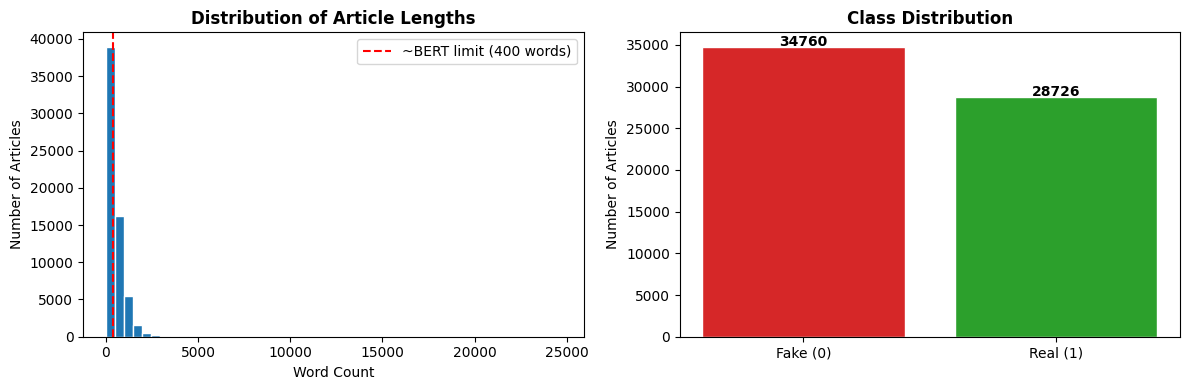


Articles over 400 words: 33536 (52.8%)
These will be truncated by the tokenizer — this is expected and handled automatically


In [9]:
import os

# BERT has a maximum sequence length of 512 tokens
# (roughly 350-400 words for English)
# We need to understand how our articles compare to this limit

combined_df['text_length'] = combined_df['text'].str.split().str.len()

print("Text length statistics (in words):")
print(combined_df['text_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of text lengths
axes[0].hist(combined_df['text_length'], bins=50,
             color='#1f77b4', edgecolor='white')
axes[0].axvline(x=400, color='red', linestyle='--',
                label='~BERT limit (400 words)')
axes[0].set_title('Distribution of Article Lengths', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Articles')
axes[0].legend()

# Label distribution
label_counts = combined_df['label'].value_counts()
axes[1].bar(['Fake (0)', 'Real (1)'], label_counts.values,
            color=['#d62728', '#2ca02c'], edgecolor='white')
axes[1].set_title('Class Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Articles')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

plt.savefig('figures/data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# What percentage of articles exceed BERT's limit?
over_limit = (combined_df['text_length'] > 400).sum()
print(f"\nArticles over 400 words: {over_limit} ({over_limit/len(combined_df)*100:.1f}%)")
print("These will be truncated by the tokenizer — this is expected and handled automatically")

In [10]:
# Full BERT fine-tuning on 70,000+ articles takes hours even on GPU
# For this project, 20,000 articles gives excellent results
# in a manageable 20-30 minutes of training

# Sample STRATIFIED — meaning we keep the same fake/real ratio as the full dataset
from sklearn.utils import resample

MAX_SAMPLES = 20000  # adjust down to 10000 if GPU runs out of memory

# Separate by class
fake_articles = combined_df[combined_df['label'] == 0]
real_articles = combined_df[combined_df['label'] == 1]

# Sample equally from each class (balanced dataset)
n_each = MAX_SAMPLES // 2

fake_sampled = resample(fake_articles, n_samples=n_each,
                         random_state=SEED, replace=False)
real_sampled = resample(real_articles, n_samples=n_each,
                         random_state=SEED, replace=False)

df = pd.concat([fake_sampled, real_sampled]).sample(
    frac=1, random_state=SEED).reset_index(drop=True)

print(f"Final dataset: {len(df)} articles")
print(f"Class balance:\n{df['label'].value_counts()}")

Final dataset: 20000 articles
Class balance:
label
1    10000
0    10000
Name: count, dtype: int64


In [11]:
# Load DistilBERT tokenizer
# This downloads ~250MB of tokenizer files from HuggingFace on first run
# Subsequent runs use the cached version

MODEL_NAME = 'distilbert-base-uncased'
# 'uncased' means text is lowercased before tokenizing
# This is standard for classification tasks

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer loaded")

# Understand what the tokenizer does with an example
sample_text = "Breaking: Government announces new AI policy for India"
tokens = tokenizer.tokenize(sample_text)
print(f"\nExample tokenization:")
print(f"Input:  '{sample_text}'")
print(f"Tokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")

# Notice: some words get split into sub-words
# e.g. "announces" might become ["announce", "##s"]
# The ## prefix means "this piece continues from the previous token"
# This lets BERT handle words it's never seen before

Loading tokenizer: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded

Example tokenization:
Input:  'Breaking: Government announces new AI policy for India'
Tokens: ['breaking', ':', 'government', 'announces', 'new', 'ai', 'policy', 'for', 'india']
Number of tokens: 9


In [12]:
# BERT processes fixed-length sequences
# Shorter texts get padded with [PAD] tokens to reach MAX_LEN
# Longer texts get truncated to MAX_LEN

# 256 is a good balance: covers most article openings while being fast
# The opening paragraphs usually contain the most useful signals for fake news
MAX_LEN = 256

# Test tokenization on one example
encoding = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding='max_length',    # pad to MAX_LEN with [PAD] tokens
    truncation=True,          # cut off at MAX_LEN if longer
    return_tensors='pt'       # return PyTorch tensors (not numpy arrays)
)

print(f"\nTokenized output keys: {list(encoding.keys())}")
print(f"input_ids shape: {encoding['input_ids'].shape}")
print(f"attention_mask shape: {encoding['attention_mask'].shape}")

# input_ids: the integer IDs for each token
# attention_mask: 1 where there's a real token, 0 where there's padding
# BERT uses the attention_mask to ignore padding tokens during processing


Tokenized output keys: ['input_ids', 'attention_mask']
input_ids shape: torch.Size([1, 256])
attention_mask shape: torch.Size([1, 256])


In [13]:
class FakeNewsDataset(Dataset):
    """
    PyTorch Dataset class for fake news articles.

    PyTorch's training loop expects data in a specific format.
    A Dataset class tells PyTorch:
    - How many samples you have (__len__)
    - How to get sample number N (__getitem__)

    The DataLoader (used later) calls these methods automatically
    to feed batches of data to the model during training.
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts          # list of article strings
        self.labels = labels        # list of 0/1 labels
        self.tokenizer = tokenizer  # the DistilBERT tokenizer
        self.max_len = max_len      # maximum sequence length

    def __len__(self):
        # Returns total number of samples
        # DataLoader uses this to know when one epoch is complete
        return len(self.texts)

    def __getitem__(self, idx):
        # Returns one sample at index idx
        # Called by DataLoader to build each batch

        text = str(self.texts[idx])
        label = int(self.labels[idx])

        # Tokenize this single text
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'    # PyTorch tensors
        )

        # .squeeze(0) removes the extra batch dimension
        # tokenizer returns shape (1, MAX_LEN), we want (MAX_LEN,)
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [14]:
# Split: 80% train, 10% validation, 10% test
# Unlike time-series (Project 1), here we CAN shuffle
# because each news article is independent

texts = df['text'].values
labels = df['label'].values

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels    # ensure equal fake/real ratio in each split
)

# Second split: split temp into 50% val, 50% test (= 10% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")

# Verify class balance in each split
for split_name, split_labels in [('Train', y_train),
                                   ('Val', y_val),
                                   ('Test', y_test)]:
    fake_pct = (split_labels == 0).mean() * 100
    real_pct = (split_labels == 1).mean() * 100
    print(f"{split_name}: {fake_pct:.0f}% fake, {real_pct:.0f}% real")

Training samples:   16000
Validation samples: 2000
Test samples:       2000
Train: 50% fake, 50% real
Val: 50% fake, 50% real
Test: 50% fake, 50% real


In [15]:
# Create Dataset objects for each split
train_dataset = FakeNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

# Verify one sample looks correct
sample = train_dataset[0]
print(f"\nSample keys: {list(sample.keys())}")
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label: {sample['label']}")

Train dataset: 16000 samples
Val dataset:   2000 samples
Test dataset:  2000 samples

Sample keys: ['input_ids', 'attention_mask', 'label']
input_ids shape: torch.Size([256])
attention_mask shape: torch.Size([256])
label: 1


In [16]:
BATCH_SIZE = 16
# Batch size 16 is safe for Colab T4 GPU with DistilBERT + MAX_LEN=256
# If you get CUDA out of memory error, reduce to 8

# DataLoader wraps your Dataset and handles:
# - Batching: groups samples into batches of BATCH_SIZE
# - Shuffling: randomises order each epoch (training only)
# - Parallel loading: uses multiple CPU workers to load data

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # shuffle training data each epoch
    num_workers=2       # 2 parallel workers for loading
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # no shuffle for validation — order doesn't matter
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches per epoch:   {len(val_loader)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Each batch shape: (16, 256) for input_ids and attention_mask")

Train batches per epoch: 1000
Val batches per epoch:   125
Batch size: 16
Each batch shape: (16, 256) for input_ids and attention_mask


In [17]:
# Load DistilBERT with a classification head on top
# num_labels=2 means binary classification (fake=0, real=1)

print(f"Loading model: {MODEL_NAME}")
print("This downloads ~250MB on first run...")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,           # binary classification
    output_attentions=False,
    output_hidden_states=False
)

# Move model to GPU
model = model.to(device)

print(f"\nModel loaded on: {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading model: distilbert-base-uncased
This downloads ~250MB on first run...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded on: cuda
Total parameters:     66,955,010
Trainable parameters: 66,955,010


In [18]:
# Training hyperparameters
EPOCHS = 3
# 3 epochs is standard for BERT fine-tuning
# More epochs usually causes overfitting on fine-tuning tasks

LEARNING_RATE = 2e-5
# 2e-5 (0.00002) is the standard learning rate for BERT fine-tuning
# Too high (like 1e-3) destroys the pre-trained weights
# Too low (like 1e-7) means the model barely updates

WARMUP_RATIO = 0.1
# Warm up learning rate for first 10% of training steps
# Starts at 0, linearly increases to LEARNING_RATE
# This prevents large early updates from destabilising pre-trained weights

# Calculate total training steps
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Epochs: {EPOCHS}")

# AdamW optimizer — Adam with weight decay
# Weight decay is a regularisation technique that prevents overfitting
# by penalising large weights
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,     # L2 regularisation coefficient
    eps=1e-8               # numerical stability parameter
)

# Learning rate scheduler
# Linearly decreases learning rate from LEARNING_RATE to 0
# after the warmup period ends
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("\nOptimizer and scheduler ready")

Total training steps: 3000
Warmup steps: 300
Epochs: 3

Optimizer and scheduler ready


In [19]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    """
    Runs one complete pass through the training data.

    For each batch:
    1. Forward pass: input → model → predictions
    2. Calculate loss: how wrong were the predictions?
    3. Backward pass: compute gradients (how to adjust weights)
    4. Update weights: take one step in the direction that reduces loss
    5. Update learning rate scheduler
    """

    model.train()   # set model to training mode
    # In training mode: dropout is active (randomly drops neurons)
    # This acts as regularisation to prevent overfitting

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch_idx, batch in enumerate(loader):
        # Move batch tensors to GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Zero out gradients from previous batch
        # If you don't do this, gradients accumulate across batches
        optimizer.zero_grad()

        # Forward pass
        # model() returns a SequenceClassifierOutput object
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels    # when you pass labels, model computes loss automatically
        )

        loss = outputs.loss      # cross-entropy loss
        logits = outputs.logits  # raw scores for each class, shape: (batch_size, 2)

        # Backward pass: compute gradients
        loss.backward()

        # Clip gradients to prevent exploding gradient problem
        # If any gradient is larger than 1.0, scale it down to 1.0
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update model weights
        optimizer.step()

        # Update learning rate
        scheduler.step()

        total_loss += loss.item()

        # Convert logits to predictions
        # argmax(dim=1) takes the class with highest score for each sample
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1


def evaluate(model, loader, device):
    """
    Evaluates model on validation or test data.
    No weight updates happen here — we're just measuring performance.
    """

    model.eval()   # set model to evaluation mode
    # In eval mode: dropout is disabled (all neurons active)
    # This gives deterministic, stable predictions

    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    # torch.no_grad() disables gradient computation
    # We don't need gradients for evaluation — saves memory and speeds up
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            # Softmax converts raw logits to probabilities (sum to 1)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1])  # probability of being real (class 1)

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1, all_preds, all_labels, all_probs

In [21]:
import time
import os

os.makedirs('saved_model', exist_ok=True);
os.makedirs('figures', exist_ok=True);

# Track metrics across epochs
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0
best_model_path = 'saved_model/best_bert_model'

print("=" * 60)
print("STARTING TRAINING")
print(f"Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print(f"Device: {device}")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    start_time = time.time()

    # Train
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    # Evaluate on validation set
    val_loss, val_acc, val_f1, _, _, _ = evaluate(
        model, val_loader, device
    )

    epoch_time = time.time() - start_time

    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\nResults for Epoch {epoch+1}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Train F1: {train_f1:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | "
          f"Val F1:   {val_f1:.4f}")
    print(f"  Time: {epoch_time/60:.1f} minutes")

    # Save best model based on validation F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"  ✓ New best model saved (Val F1: {val_f1:.4f})")

print(f"\nTraining complete. Best Val F1: {best_val_f1:.4f}")

STARTING TRAINING
Epochs: 3 | Batch size: 16 | LR: 2e-05
Device: cuda

Epoch 1/3
----------------------------------------
  Batch 100/1000 | Loss: 0.0013
  Batch 200/1000 | Loss: 0.0009
  Batch 300/1000 | Loss: 0.0016
  Batch 400/1000 | Loss: 0.0019
  Batch 500/1000 | Loss: 0.0014
  Batch 600/1000 | Loss: 0.0012
  Batch 700/1000 | Loss: 0.0024
  Batch 800/1000 | Loss: 0.0006
  Batch 900/1000 | Loss: 0.0007
  Batch 1000/1000 | Loss: 0.0035

Results for Epoch 1:
  Train Loss: 0.0414 | Train Acc: 0.9889 | Train F1: 0.9889
  Val Loss:   0.1194 | Val Acc:   0.9730 | Val F1:   0.9730
  Time: 6.6 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (Val F1: 0.9730)

Epoch 2/3
----------------------------------------
  Batch 100/1000 | Loss: 0.0007
  Batch 200/1000 | Loss: 0.3499
  Batch 300/1000 | Loss: 0.0007
  Batch 400/1000 | Loss: 0.0010
  Batch 500/1000 | Loss: 0.0010
  Batch 600/1000 | Loss: 0.0004
  Batch 700/1000 | Loss: 0.0005
  Batch 800/1000 | Loss: 0.0004
  Batch 900/1000 | Loss: 0.0004
  Batch 1000/1000 | Loss: 0.1145

Results for Epoch 2:
  Train Loss: 0.0157 | Train Acc: 0.9961 | Train F1: 0.9961
  Val Loss:   0.1223 | Val Acc:   0.9735 | Val F1:   0.9735
  Time: 6.8 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (Val F1: 0.9735)

Epoch 3/3
----------------------------------------
  Batch 100/1000 | Loss: 0.0008
  Batch 200/1000 | Loss: 0.0005
  Batch 300/1000 | Loss: 0.0006
  Batch 400/1000 | Loss: 0.0005
  Batch 500/1000 | Loss: 0.0012
  Batch 600/1000 | Loss: 0.0008
  Batch 700/1000 | Loss: 0.0005
  Batch 800/1000 | Loss: 0.0004
  Batch 900/1000 | Loss: 0.0009
  Batch 1000/1000 | Loss: 0.0012

Results for Epoch 3:
  Train Loss: 0.0110 | Train Acc: 0.9972 | Train F1: 0.9972
  Val Loss:   0.1223 | Val Acc:   0.9735 | Val F1:   0.9735
  Time: 6.8 minutes

Training complete. Best Val F1: 0.9735


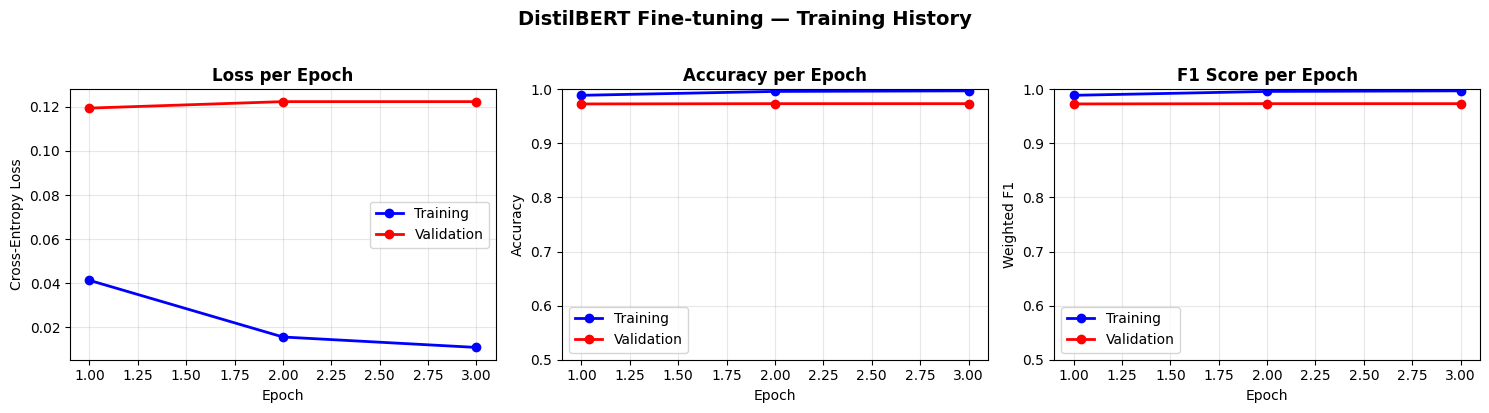

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'],
             'b-o', label='Training', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],
             'r-o', label='Validation', linewidth=2)
axes[0].set_title('Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'],
             'b-o', label='Training', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],
             'r-o', label='Validation', linewidth=2)
axes[1].set_title('Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.5, 1.0])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(epochs_range, history['train_f1'],
             'b-o', label='Training', linewidth=2)
axes[2].plot(epochs_range, history['val_f1'],
             'r-o', label='Validation', linewidth=2)
axes[2].set_title('F1 Score per Epoch', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Weighted F1')
axes[2].set_ylim([0.5, 1.0])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('DistilBERT Fine-tuning — Training History',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Load the best model (highest val F1) for final evaluation
print("Loading best model for final evaluation...")
best_model = DistilBertForSequenceClassification.from_pretrained(best_model_path)
best_model = best_model.to(device)

# Evaluate on test set
test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(
    best_model, test_loader, device
)

print("\n" + "=" * 60)
print("FINAL TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"F1 Score:  {test_f1:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print("=" * 60)

# Detailed classification report
# Shows precision, recall, F1 for each class separately
print("\nDetailed Classification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=['Fake News', 'Real News'],
    digits=4
))

Loading best model for final evaluation...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


FINAL TEST SET PERFORMANCE
Accuracy:  0.9750 (97.5%)
F1 Score:  0.9750
Test Loss: 0.1105

Detailed Classification Report:
              precision    recall  f1-score   support

   Fake News     0.9750    0.9750    0.9750      1000
   Real News     0.9750    0.9750    0.9750      1000

    accuracy                         0.9750      2000
   macro avg     0.9750    0.9750    0.9750      2000
weighted avg     0.9750    0.9750    0.9750      2000



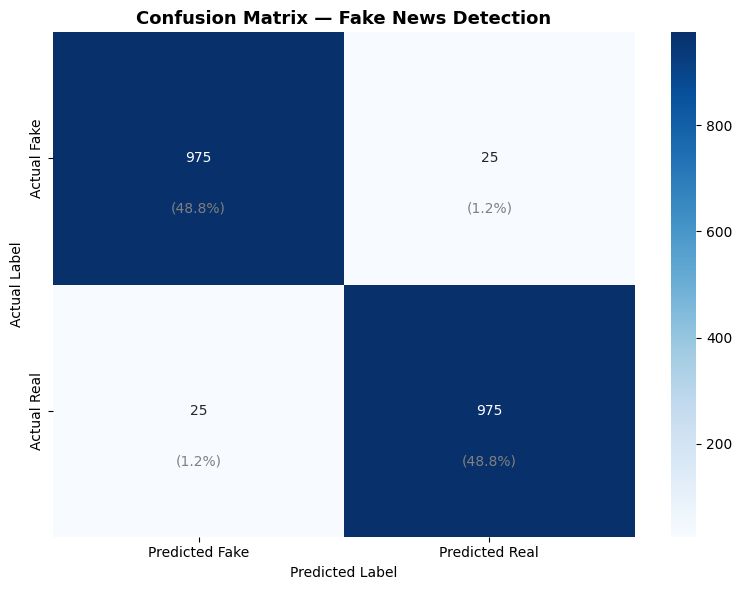


Confusion Matrix Breakdown:
True Negatives  (correctly identified fake):  975
False Positives (real news called fake):      25
False Negatives (fake news missed):           25
True Positives  (correctly identified real):  975


In [24]:
# Confusion matrix shows exactly where the model makes errors
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',              # display as integers
    cmap='Blues',
    xticklabels=['Predicted Fake', 'Predicted Real'],
    yticklabels=['Actual Fake', 'Actual Real']
)
plt.title('Confusion Matrix — Fake News Detection',
          fontweight='bold', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Add percentage annotations
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        plt.text(j + 0.5, i + 0.7, f'({pct:.1f}%)',
                ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives  (correctly identified fake):  {tn}")
print(f"False Positives (real news called fake):      {fp}")
print(f"False Negatives (fake news missed):           {fn}")
print(f"True Positives  (correctly identified real):  {tp}")

In [25]:
# Look at examples the model got wrong — this is genuinely insightful
# and worth discussing in your README

test_df_results = pd.DataFrame({
    'text': X_test,
    'actual': test_labels,
    'predicted': test_preds,
    'confidence': test_probs  # probability of being real
})

# False positives: real news predicted as fake
false_positives = test_df_results[
    (test_df_results['actual'] == 1) &
    (test_df_results['predicted'] == 0)
].sort_values('confidence')  # lowest confidence = most wrong

print("Examples of REAL news incorrectly classified as FAKE:")
print("(These are cases where the model was most uncertain)")
for _, row in false_positives.head(3).iterrows():
    print(f"\nText preview: {row['text'][:200]}...")
    print(f"Confidence of being real: {row['confidence']:.3f}")
    print("-" * 50)

# False negatives: fake news predicted as real
false_negatives = test_df_results[
    (test_df_results['actual'] == 0) &
    (test_df_results['predicted'] == 1)
].sort_values('confidence', ascending=False)

print("\nExamples of FAKE news incorrectly classified as REAL:")
for _, row in false_negatives.head(3).iterrows():
    print(f"\nText preview: {row['text'][:200]}...")
    print(f"Confidence of being real: {row['confidence']:.3f}")
    print("-" * 50)

Examples of REAL news incorrectly classified as FAKE:
(These are cases where the model was most uncertain)

Text preview: Merkel says Facebook, Google  distort perception,  demands they  reveal algorithms   German Chancellor Angela Merkel launched a broadside at internet media giants, accusing them of  narrowing perspect...
Confidence of being real: 0.000
--------------------------------------------------

Text preview: Bernie Sanders Rocked 3 Rallies In Florida Yesterday  Yesterday, Senator Bernie Sanders swept through North Florida, holding rallies in Gainesville, Tampa Bay, and Kissimee  outside of Orlando , with ...
Confidence of being real: 0.000
--------------------------------------------------

Text preview: Feds Find Local Police Willing Partners in Surveillance State  "A man must keep a little back shop where he can be himself without reserve. In solitude alone can he know true freedom."   Michel de Mon...
Confidence of being real: 0.000
--------------------------------------

In [26]:
def predict_fake_news(text):
    """
    Takes a news article text string and returns:
    - The classification (Fake / Real)
    - Confidence percentages for both classes

    This is the function Gradio will call when a user submits text.
    """

    if not text or len(text.strip()) < 20:
        return "Please enter a longer text (at least 20 characters)"

    # Tokenize the input
    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Get prediction
    best_model.eval()
    with torch.no_grad():
        outputs = best_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    fake_prob = probs[0] * 100
    real_prob = probs[1] * 100
    prediction = "🟢 REAL NEWS" if probs[1] > probs[0] else "🔴 FAKE NEWS"
    confidence = max(fake_prob, real_prob)

    result = f"""
**Prediction: {prediction}**

Confidence: {confidence:.1f}%

---
- Probability of being Real: {real_prob:.1f}%
- Probability of being Fake: {fake_prob:.1f}%

*Note: This model was trained on English news articles.
Results may vary for short or out-of-domain text.*
"""
    return result


# Test it
sample_fake = """
BREAKING: Scientists discover that drinking water causes cancer,
government hiding the truth for decades. Insider sources reveal
massive coverup by pharmaceutical companies and WHO.
Share before they delete this!
"""

sample_real = """
The Reserve Bank of India maintained its benchmark interest rate
at 6.5% on Friday, as widely expected, while maintaining its
focus on withdrawing accommodation to ensure inflation progressively
aligns with the target while supporting growth.
"""

print("Testing prediction function:")
print("Sample 1 (likely fake):")
print(predict_fake_news(sample_fake))
print("\nSample 2 (likely real):")
print(predict_fake_news(sample_real))

Testing prediction function:
Sample 1 (likely fake):

**Prediction: 🟢 REAL NEWS**

Confidence: 99.9%

---
- Probability of being Real: 99.9%
- Probability of being Fake: 0.1%

*Note: This model was trained on English news articles. 
Results may vary for short or out-of-domain text.*


Sample 2 (likely real):

**Prediction: 🔴 FAKE NEWS**

Confidence: 99.9%

---
- Probability of being Real: 0.1%
- Probability of being Fake: 99.9%

*Note: This model was trained on English news articles. 
Results may vary for short or out-of-domain text.*



In [28]:
# Create the Gradio interface
interface = gr.Interface(
    fn=predict_fake_news,

    inputs=gr.Textbox(
        lines=8,
        placeholder="Paste a news article here...",
        label="News Article Text"
    ),

    outputs=gr.Markdown(label="Analysis Result"),

    title="Fake News Detector — India News Context",

    description="""
    **Fine-tuned DistilBERT model for fake news detection.**

    Paste any English news article text and the model will classify it
    as likely Real or Fake, with confidence scores.

    *Built as part of a Masters application portfolio project.
    Model trained on WELFake dataset (20,000 articles).
    For educational purposes only — always verify news from primary sources.*
    """,

    examples=[
        ["The Indian government announced a new AI policy framework today, "
         "establishing guidelines for responsible AI deployment across public "
         "sector organisations. The policy includes provisions for data "
         "privacy, algorithmic accountability, and digital literacy programs."],

        ["SHOCKING: Doctors don't want you to know this one trick that cures "
         "diabetes in 3 days using common kitchen ingredients. Big Pharma is "
         "trying to suppress this information. Share widely before it's deleted!"],
    ],

    theme=gr.themes.Soft()   # clean, professional theme
)

# Launch with share=True creates a public URL valid for 72 hours
# This is the URL you put in your README
print("Launching Gradio demo...")
interface.launch(share=True, debug=False)

# Copy the public URL that appears — it looks like:
# https://xxxxxxxx.gradio.live
# This is your live demo link

Launching Gradio demo...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3ccb38297a368fbe42.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [29]:
import shutil

os.makedirs('github_upload', exist_ok=True)
os.makedirs('github_upload/figures', exist_ok=True)

# Copy figures
for fig_file in os.listdir('figures/'):
    shutil.copy(f'figures/{fig_file}', f'github_upload/figures/{fig_file}')

# Save the model (already saved to saved_model/)
# For GitHub, the model is too large to upload directly
# We'll save the config and note where to download weights

# Save requirements
with open('github_upload/requirements.txt', 'w') as f:
    f.write("""transformers>=4.30.0
torch>=2.0.0
gradio>=3.35.0
datasets>=2.12.0
accelerate>=0.20.0
pandas>=1.5.0
numpy>=1.23.0
scikit-learn>=1.2.0
matplotlib>=3.7.0
seaborn>=0.12.0
""")

print("Files ready for GitHub upload")
print("Remember to also download your .ipynb notebook:")
print("File → Download → Download .ipynb")

Files ready for GitHub upload
Remember to also download your .ipynb notebook:
File → Download → Download .ipynb
